# **Week 5: Data Structures**

## **Abstract Data types**
- Queues
- Stacks


### 1.1 **Queues**: 
**FIFO** - first in first out

2 actions for queues
- `enqueue` - add to queue
- `dequeue` - remove from queue

In [ ]:
// basic queue structure
const int CAPACITY;

typedef struct 
{
    person people[CAPACITY];
    int size;
} queue;

### 1.2 **Stack**
**LIFO** - last in first out

2 fundamental operations
- `push`: put to top of stack
- `pop`: remove from top of stack

In [ ]:
// basic queue structure
const int CAPACITY;

typedef struct 
{
    person people[CAPACITY];
    int size;
} stack;

### 1.3 **Dictionaries**
A collection of `key:value` pair

### **Arrays**
A collection of values

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main(void)
{
    // int list[3];  // static memory allocation
    int *list = malloc(3 * sizeof(int)); // space for 3 integers

    list[0] = 1; // or *list = 1;
    list[1] = 2; // or *(list + 1) = 2;
    list[2] = 3; // or *(list + 2) = 3;

    for (int i = 0; i < 3; i++)
    {

        printf("%i \n", list[i]);
    }
}

1 
2 
3 


> Note: `malloc` returns the memory address for the first item of an array

### **Dynamic Memory Allocation**
The manual way is to copy the current list to a new list with a needed space or use `realloc` - the preferred inbuilt function from `<stdlib.h>`

```c
realloc(originalItem, newSize)
//eg:
realloc(list, 4 * sizeof(int))
```

In [1]:
//%cflags:-lcs50
// v1 - without `realloc`
#include <stdio.h>
#include <stdlib.h>

int main(void)
{
    // store 3 integers
    int *list = malloc(3 * sizeof(int));
    if (list == NULL)
    {
        return 1;
    }

    list[0] = 1;
    list[1] = 2;
    list[2] = 3;

    // time passes, store 4 intergers, by first creating a temporary list with the 4th update
    // and pointing the original list address to this temporary address
    int *tmp = malloc(4 * sizeof(int));
    if (tmp == NULL)
    {
        free(list);
        return 1;
    }

    // copy old list into new list
    for (int i = 0; i < 3; i++)
    {
        tmp[i] = list[i];
    }
    tmp[3] = 4;

    // free original list
    free(list);

    list = tmp;

    for (int i = 0; i < 4; i++)
    {
        printf("%i\n", list[i]);
    }
    

    free(list);
    return 0;
}

1
2
3
4


`realloc` will try to grow the (contiguous) list if there is room more to the end else it would copy to a new location with more memory.

In [1]:
//%cflags:-lcs50
#include <stdio.h>
#include <stdlib.h>

int main(void)
{
    // store 3 integers
    int *list = malloc(3 * sizeof(int));
    if (list == NULL)
    {
        return 1;
    }

    list[0] = 1;
    list[1] = 2;
    list[2] = 3;

    // time passes
    int *tmp = realloc(list, 4 * sizeof(int));
    if (tmp == NULL)
    {
        free(list);
        return 1;
    }

    tmp[3] = 4;

    list = tmp;

    for (int i = 0; i < 4; i++)
    {
        printf("%i\n", list[i]);
    }

    free(list);
    return 0;
}

1
2
3
4


## **Data Structures**
Useful operators
```c
struct
.
*
```

```c
. + * = ->
```

### **Linked list**
#### **A: Singly Linked Lists**
A type of array that isn't contiguous in memory. It can be stored in increasing sizes somewhat scattered in memory but always has a reference (pointers) to each other.

- You can't use `++` to go to the next item.
- It works by storing a metadata (or a pointer in a small portion of memory) next to the list item that points to the next item in the list.
- The data+metadata combo is referred to as a `node`

> In python an array is in-fact a linked list

Structure of a linked list
```c
typedef struct node
{
    int number;
    struct node *next; 
} node;

```

> For a singly linked list, the pointers only point in one direction

In [ ]:
//%cflags:-lcs50
// Example of linked list
#include <stdio.h>
#include <stdlib.h>
#include <cs50.h>

typedef struct node
{
    int number;
    struct node *next;
} node;

int main(void)
{
    node *list = NULL;

    for (int i = 0; i < 3; i++)
    {
        node *n = malloc(sizeof(node));

        if (n == NULL)
        {
            return 1;
        }

        n->number = get_int("Number: ");
        n->next = NULL;

        // prepend(insert at beginning) node to the list
        n->next = list;
        list = n;
    }

    // print numbers
    node *ptr = list;
    while (ptr != NULL)
    {
        printf("%i\n", ptr->number);
        ptr = ptr->next;
    }
    // OR: alternative to print numbers
    // for (node *ptr = list; ptr != NULL; ptr = ptr->next)
    // {
    //     printf("%i\n", ptr->number);
    // }

    return 0;
}

// (*n).number = get_int("Number: ") is qual to  n->number = get_int("Number: "); go the "n" node and point to the number feild
// memory leak: when you lose a pointer to a chunk of useful data

Number: 

##### **Running times of linked list operations** 

**Insertion**
- `O(1)` - we only prepend to the start of the list

**Searching, Deletion & Sorting**  
- `O(n)` - you will at least search through the whole list to perform these operations


##### **Sorted Linked list**  
**Running times**
- **Insertion, Deletion, Searching:** `O(n)`


  
    
    

### **B: Doubly Linked List**
For doubly linked list the pointers to nodes point in both direction from a given node.

> **NOTE**:
> - Arrays are very simple and quite efficient with the basic read, search, delete operations. But there was one big problem - since they are stored in a contiguous fashion, we may run into a problem where there may not be any more room left at the end to store any additional items. The solution to this is to copy the whole list to a different memory location with more space with using `malloc` or `realloc`. But this can make arrays unsuitable when it happens to an array with a very large number of items, the copying process can greatly affect its performance.
>
> - Linked list are a great solution for this Array's problem. They do not require items to be stored in a contiguous manner, they simply store the data at any available location and store and additional metadata and pointer linking to the nest item. But this also has a problem. The basic operations infact become less inefficient than arrays and it greatly affects binary operations, which rely on finding the middle point of the array/list for each step (and this takes `O(n)` steps to just find the middle of the list).
>
> - A solution to this problem is `trees`, they combine the good traits of Arrays and Linked lists into one unified data structure. 

### **Trees**
**Benefits of binary trees**
- 2 dimensional (**Binary search tree**)
- **Running times can be very efficient**:
    - Search: O $\log(n)$
    - Insert: O $\log(n)$

- Height of binary tree: $log_{2}(n)$

**Downsides of binary tress**
- **Uses three times more memory**. May not be the best for large number of nodes.
    - Each node stores the integer or data itself plus 2 additional pointers (except for `leave nodes`, the ones at the bottom of the tree) resulting to a total of 25+ bytes for each node compared to about 12 for linked lists or just 4bytes for arrays. The main middle node is called the `root`.

**Structure of a binary tree**
```c
typedef struct node
{
    int number;  // data
    struct node *left;  // piece of data to track left nodes
    struct node *right; // ..to tract right nodes, In all it uses 3 times as much data as a regular array
} node;

```


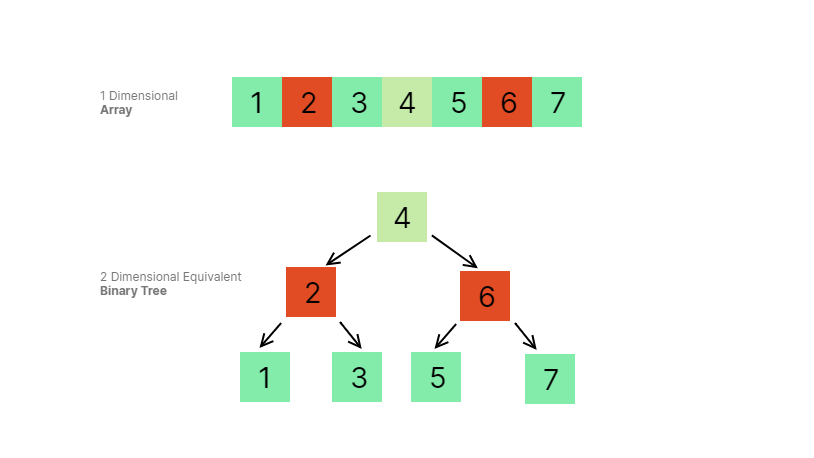


img 1: diagram of the similarities between a 1 dimensional array and 2 dimensional binary tree.

##### **Implementations**
Below is a pseudocode for performing a search operation on a binary tree, using recursion

```c
bool search(node *tree, int number){
    if(tree == NULL){
        return false;
    } else if (number < tree->number) // tree->number = peek into node?
    {
        return search(tree->left, number);
    } else if (number > tree-> number)
    {
        return search(tree->right, number)
    } else
    {
        return true;
    }
}
```

### **Hashing**
We can future improve running times of operations on binary trees or in general by employing hashing, with the goal of getting closer to or achieving constant time $Olog(1)$.

*_Hashing_ is taking values from an infinite domain(range) and mapping them to a finite set of options/value (to bucketize)*

---

A **hash function** is used to map what inputs maps to what outputs.  
A **hash table** is a data structure used to store a key value pairs with hashing and hash functions. It resembles a mashup of an array with linked list.

---

```c
// array of pointers
node *table[26]   
// a node of a linked list for the table
typedef struct node
{
    char *name; // data
    struct node *next; // pointer
}

```

With an optimized hash function, we can produce a has table that gets us closer to this $O(1)$ goal (like sub hash tables for similar collision keys/items), but the general running times for hash tables is still $O(N)$ although it is several times more faster than the data structures we've seen so far.

### **Tries (retrievals?)**
A data structure of a tree made up of arrays.

```c
typedef struct node
{
    struct node *children[26]; // each node is an array of a defined length/size
    char *number; // value stored
} node;

```

This infact achieves a constant time, $O(1)$ in all operations (reading, writing...). The the very big problem is it does this by wasting a lot of memory, most entries in each node (of the 26 or whatever size defined) is mostly empty.